In [1]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import mne

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}


In [2]:
task = 'Active'
file_path = f'Fit_{task}_late'
os.makedirs(file_path, exist_ok=True)
    
audibilities_all_parts, state_train_all_parts = [], []
state_train_early_all_parts = []

for part in tqdm(range(20)):
    # part = 18

    # Load data
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref

    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    audibility = epochs.metadata['audibility'].to_numpy()
    snr = epochs.metadata['snr'].to_numpy()
    audibilities_all_parts.append(audibility)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=300, tmax=500, sort_by_snr=False)
        state_train_all_parts.append(state_train)
        state_train_early = lead.STG(epochs_file, tmin=100, tmax=200, sort_by_snr=False)
        state_train_early_all_parts.append(state_train_early)

  0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_338485/2383470878.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_338485/2383470878.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_338485/2383470878.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_338485/2383470878.py:16: RuntimeWarni

In [3]:
state_train_dict = {aud: [] for aud in range(11)}
state_train_early_dict = {aud: [] for aud in range(11)}
for part in range(20):
    for aud in np.unique(audibilities_all_parts[part]):
        subset = state_train_all_parts[part][audibilities_all_parts[part] == aud]
        subset_early = state_train_early_all_parts[part][audibilities_all_parts[part] == aud]

        # If the filtered result is a list/array of trials, keep each trial as its own item.
        # If it is already a single trial vector, keep it as a single element.
        if isinstance(subset, np.ndarray):
            if subset.ndim > 1:
                subset = subset.tolist()
                subset_early = subset_early.tolist()
            else:
                subset = [subset]
                subset_early = [subset_early]

        if isinstance(subset, (list, tuple)) and subset and isinstance(subset[0], (list, tuple, np.ndarray)):
            state_train_dict[aud].extend(subset)
            state_train_early_dict[aud].extend(subset_early)
        else:
            state_train_dict[aud].append(subset)
            state_train_early_dict[aud].append(subset_early)


In [4]:
for aud in state_train_dict.keys():
    state_train_dict[aud] = np.array(state_train_dict[aud])
    state_train_early_dict[aud] = np.array(state_train_early_dict[aud])

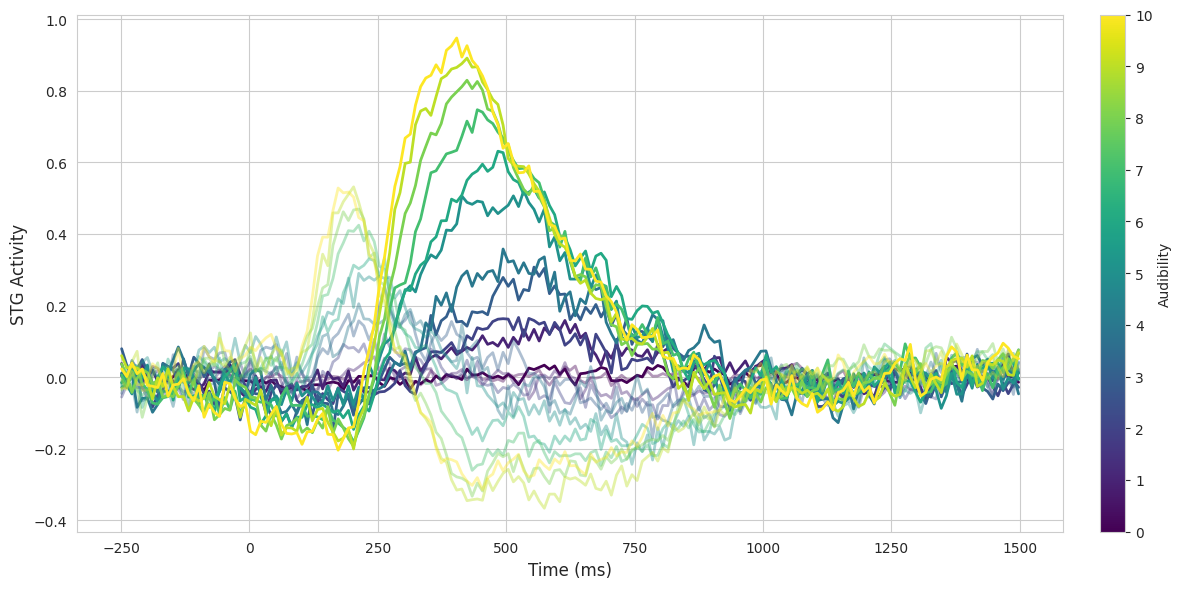

In [5]:
times = np.linspace(-500, 2000, 250)

plt.figure(figsize=(13, 6))
sns.set_style('whitegrid')

cmap = plt.get_cmap('viridis')
norm = plt.Normalize(0, 10)

for aud in range(11):
    signal = state_train_dict[aud].mean(axis=0)
    plt.plot(
        times[25:200],
        signal[25:200],
        color=cmap(norm(aud)),
        linewidth=2,
        alpha=1,
    )

    signal_early = state_train_early_dict[aud].mean(axis=0)
    plt.plot(
        times[25:200],
        signal_early[25:200],
        color=cmap(norm(aud)),
        linewidth=2,
        alpha=0.4,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
colorbar = plt.colorbar(sm, ax=plt.gca(), pad=0.03)
colorbar.set_label('Audibility')
colorbar.set_ticks(np.arange(0, 11, 1))

plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('STG Activity', fontsize=12)
# plt.title(f'STG Activity by Audibility', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
inter_trial_std_dict = {aud: [] for aud in range(11)}
for part in tqdm(range(20)):
    for aud in range(11):
        inter_trial_std = np.std(state_train_all_parts[part][audibilities_all_parts[part]==aud], axis=0)
        # print(f"Part {part}, Audibility {aud}: inter_trial_std shape: {inter_trial_std.shape}")
        inter_trial_std_dict[aud].append(inter_trial_std)

for aud in inter_trial_std_dict.keys():
    inter_trial_std_dict[aud] = np.array(inter_trial_std_dict[aud])

# 95% confidence interval for the variability mean at each audibility level.
# Most common approach: mean +/- 1.96 * SEM, where SEM = SD / sqrt(n)
window = (times >= 400) & (times <= 500)

mean_variability_by_aud = []
ci95_by_aud = []

for aud in range(11):
    if inter_trial_std_dict[aud].size == 0:
        mean_variability_by_aud.append(np.nan)
        ci95_by_aud.append(np.nan)
        continue

    subject_window_means = np.array([
        np.mean(subj_std[window])
        for subj_std in inter_trial_std_dict[aud]
    ])

    mean_val = subject_window_means.mean()
    if subject_window_means.size > 1:
        sem = subject_window_means.std(ddof=1) / np.sqrt(subject_window_means.size)
        ci95 = 1.96 * sem
    else:
        ci95 = 0.0

    mean_variability_by_aud.append(mean_val)
    ci95_by_aud.append(ci95)

  0%|          | 0/20 [00:00<?, ?it/s]

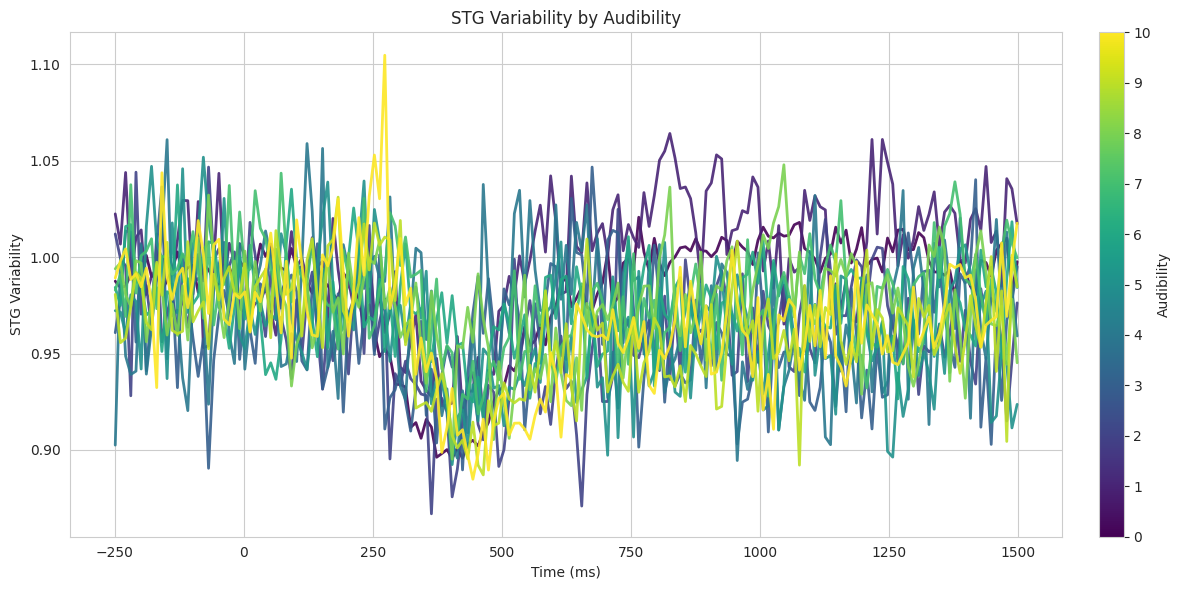

In [7]:
times = np.linspace(-500, 2000, 250)

plt.figure(figsize=(13, 6))
sns.set_style('whitegrid')

cmap = plt.get_cmap('viridis')
norm = plt.Normalize(0, 10)

for aud in range(11):
    signal = inter_trial_std_dict[aud].mean(axis=0)
    plt.plot(
        times[25:200],
        signal[25:200],
        color=cmap(norm(aud)),
        linewidth=2,
        alpha=0.9,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
colorbar = plt.colorbar(sm, ax=plt.gca(), pad=0.03)
colorbar.set_label('Audibility')
colorbar.set_ticks(np.arange(0, 11, 1))

plt.xlabel('Time (ms)')
plt.ylabel('STG Variability')
plt.title(f'STG Variability by Audibility')
plt.tight_layout()
plt.show()

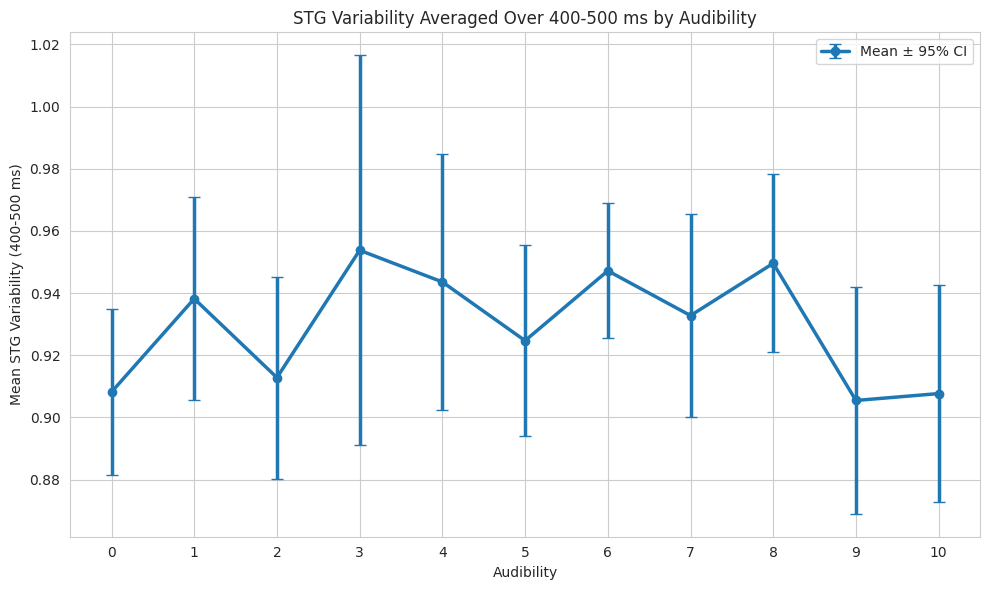

In [8]:
# variability averaged over the 400-500 ms window, for each audibility level, with 95% CI
mean_variability_by_aud = np.asarray(mean_variability_by_aud, dtype=float)
ci95_by_aud = np.asarray(ci95_by_aud, dtype=float)
valid = ~np.isnan(mean_variability_by_aud)

plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

plt.errorbar(
    np.arange(11)[valid],
    mean_variability_by_aud[valid],
    yerr=ci95_by_aud[valid],
    fmt='o-',
    capsize=4,
    markersize=6,
    linewidth=2.5,
    color='C0',
    label='Mean ± 95% CI'
)

plt.xticks(np.arange(11))
plt.xlabel('Audibility')
plt.ylabel('Mean STG Variability (400-500 ms)')
plt.title('STG Variability Averaged Over 400-500 ms by Audibility')
plt.legend()
plt.tight_layout()
plt.show()

# The sorted_by_snr counterpart

In [9]:
task = 'Active'
file_path = f'Fit_{task}_late'
os.makedirs(file_path, exist_ok=True)
    
snrs_all_parts_snrwise, state_train_all_parts_snrwise = [], []
state_train_all_parts_snrwise_early = []

for part in tqdm(range(20)):
    # part = 18

    # Load data
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref

    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    audibility = epochs.metadata['audibility'].to_numpy()
    snr = epochs.metadata['snr'].to_numpy()
    snrs_all_parts_snrwise.append(snr)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=300, tmax=500, sort_by_snr=True)
        state_train_all_parts_snrwise.append(state_train)
        state_train_early = lead.STG(epochs_file, tmin=100, tmax=200, sort_by_snr=True)
        state_train_all_parts_snrwise_early.append(state_train_early)


  0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_338485/2655712667.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_338485/2655712667.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_338485/2655712667.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_338485/2655712667.py:16: RuntimeWarni

In [10]:
state_train_dict_snrwise = {snr: [] for snr in range(1, 7)}
state_train_dict_snrwise_early = {snr: [] for snr in range(1, 7)}
for part in range(20):
    for snr in range(1, 7):
        subset = state_train_all_parts_snrwise[part][snr - 1]
        subset_early = state_train_all_parts_snrwise_early[part][snr - 1]

        # If the filtered result is a list/array of trials, keep each trial as its own item.
        # If it is already a single trial vector, keep it as a single element.
        if isinstance(subset, np.ndarray):
            if subset.ndim > 1:
                subset = subset.tolist()
                subset_early = subset_early.tolist()
            else:
                subset = [subset]
                subset_early = [subset_early]

        if isinstance(subset, (list, tuple)) and subset and isinstance(subset[0], (list, tuple, np.ndarray)):
            state_train_dict_snrwise[snr].extend(subset)
            state_train_dict_snrwise_early[snr].extend(subset_early)
        else:
            state_train_dict_snrwise[snr].append(subset)
            state_train_dict_snrwise_early[snr].append(subset_early)

In [11]:
for snr in state_train_dict_snrwise.keys():
    state_train_dict_snrwise[snr] = np.array(state_train_dict_snrwise[snr])
    state_train_dict_snrwise_early[snr] = np.array(state_train_dict_snrwise_early[snr])

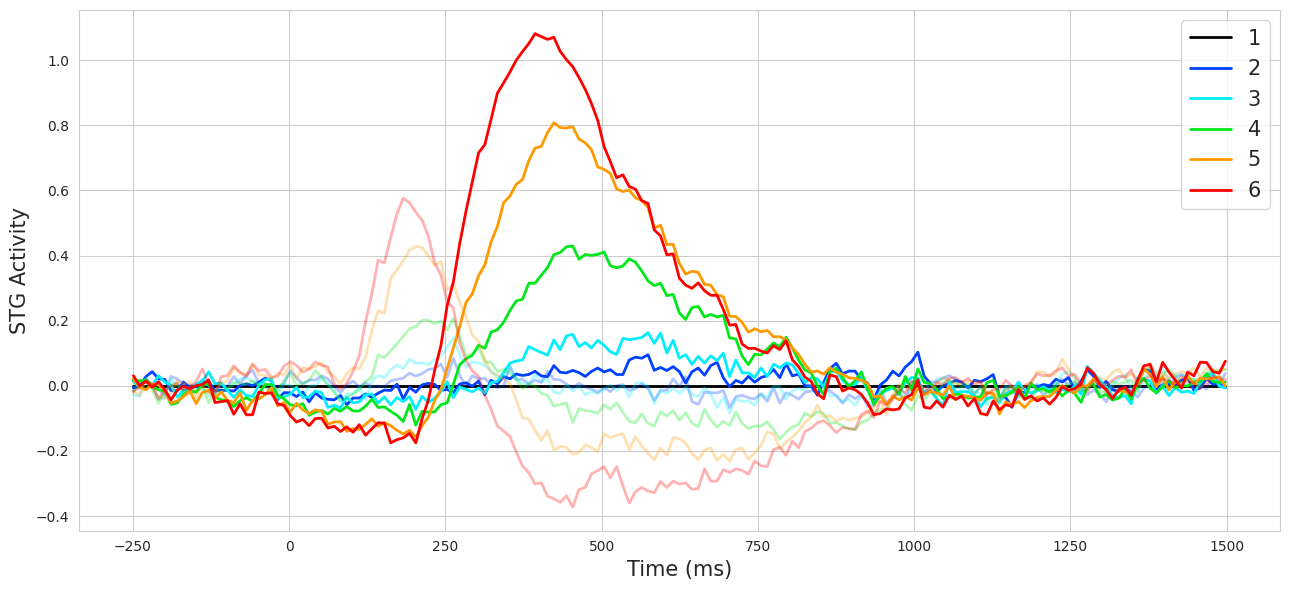

In [12]:
from matplotlib.colors import ListedColormap, Normalize

times = np.linspace(-500, 2000, 250)

plt.figure(figsize=(13, 6))
sns.set_style('whitegrid')

snr_levels = [-13, -11, -9, -7, -5, -3]
custom_colors = [colormap[i] for i in range(1, 7)]
cmap = ListedColormap(custom_colors, name='snr_custom')
norm = Normalize(vmin=1, vmax=6)

for snr in range(1, 7):
    signal = state_train_dict_snrwise[snr].mean(axis=0)
    plt.plot(
        times[25:200],
        signal[25:200],
        color=colormap[snr-1],
        linewidth=2,
        alpha=1,
        label=str(snr)
    )

    signal_early = state_train_dict_snrwise_early[snr].mean(axis=0)
    plt.plot(
        times[25:200],
        signal_early[25:200],
        color=colormap[snr-1],
        linewidth=2,
        alpha=0.3,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# colorbar = plt.colorbar(sm, ax=plt.gca(), pad=0.03, ticks=np.arange(1, 7))
# colorbar.set_label('SNR (dB)')
# colorbar.set_ticklabels([str(level) for level in snr_levels])

plt.xlabel('Time (ms)', fontsize=15)
plt.ylabel('STG Activity', fontsize=15)
# plt.title(f'STG Activity by SNR', fontsize=12)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

In [13]:
inter_trial_std_dict_snrwise = {snr: [] for snr in range(1, 7)}
for part in tqdm(range(20)):
    for snr in range(1, 7):
        inter_trial_std = np.std(state_train_all_parts_snrwise[part][snr - 1], axis=0)
        # print(f"Part {part}, SNR {snr}: inter_trial_std shape: {inter_trial_std.shape}")
        inter_trial_std_dict_snrwise[snr].append(inter_trial_std)

for snr in inter_trial_std_dict_snrwise.keys():
    inter_trial_std_dict_snrwise[snr] = np.array(inter_trial_std_dict_snrwise[snr])

# 95% confidence interval for the variability mean at each SNR level.
# Most common approach: mean +/- 1.96 * SEM, where SEM = SD / sqrt(n)
window = (times >= 400) & (times <= 500)

mean_variability_by_snr = []
ci95_by_snr = []

for snr in range(1, 7):
    if inter_trial_std_dict_snrwise[snr].size == 0:
        mean_variability_by_snr.append(np.nan)
        ci95_by_snr.append(np.nan)
        continue

    subject_window_means = np.array([
        np.mean(subj_std[window])
        for subj_std in inter_trial_std_dict_snrwise[snr]
    ])

    mean_val = subject_window_means.mean()
    if subject_window_means.size > 1:
        sem = subject_window_means.std(ddof=1) / np.sqrt(subject_window_means.size)
        ci95 = 1.96 * sem
    else:
        ci95 = 0.0

    mean_variability_by_snr.append(mean_val)
    ci95_by_snr.append(ci95)


  0%|          | 0/20 [00:00<?, ?it/s]

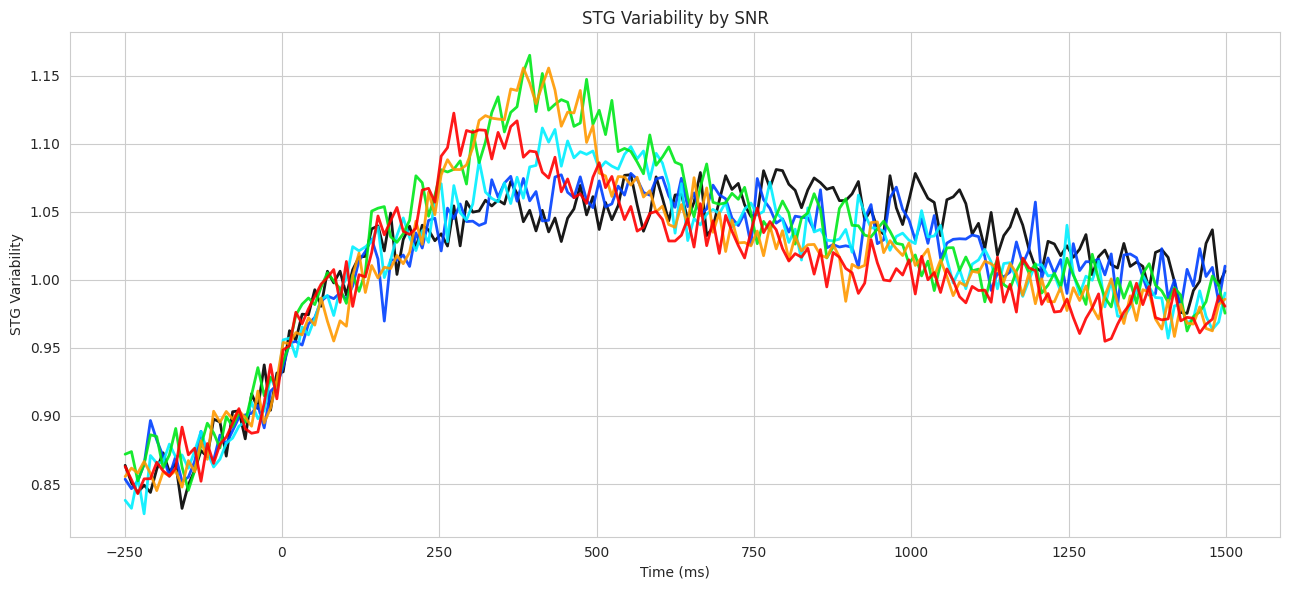

In [14]:
times = np.linspace(-500, 2000, 250)

plt.figure(figsize=(13, 6))
sns.set_style('whitegrid')

snr_levels = [-13, -11, -9, -7, -5, -3]
custom_colors = [colormap[i] for i in range(1, 7)]
cmap = ListedColormap(custom_colors, name='snr_custom')
norm = Normalize(vmin=1, vmax=6)

for snr in range(1, 7):
    signal = inter_trial_std_dict_snrwise[snr].mean(axis=0)
    plt.plot(
        times[25:200],
        signal[25:200],
        color=colormap[snr-1],
        linewidth=2,
        alpha=0.9,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# colorbar = plt.colorbar(sm, ax=plt.gca(), pad=0.03)
# colorbar.set_label('SNR')
# colorbar.set_ticks(np.arange(1, 7))
# colorbar.set_ticklabels([str(level) for level in snr_levels])

plt.xlabel('Time (ms)')
plt.ylabel('STG Variability')
plt.title(f'STG Variability by SNR')
plt.tight_layout()
plt.show()

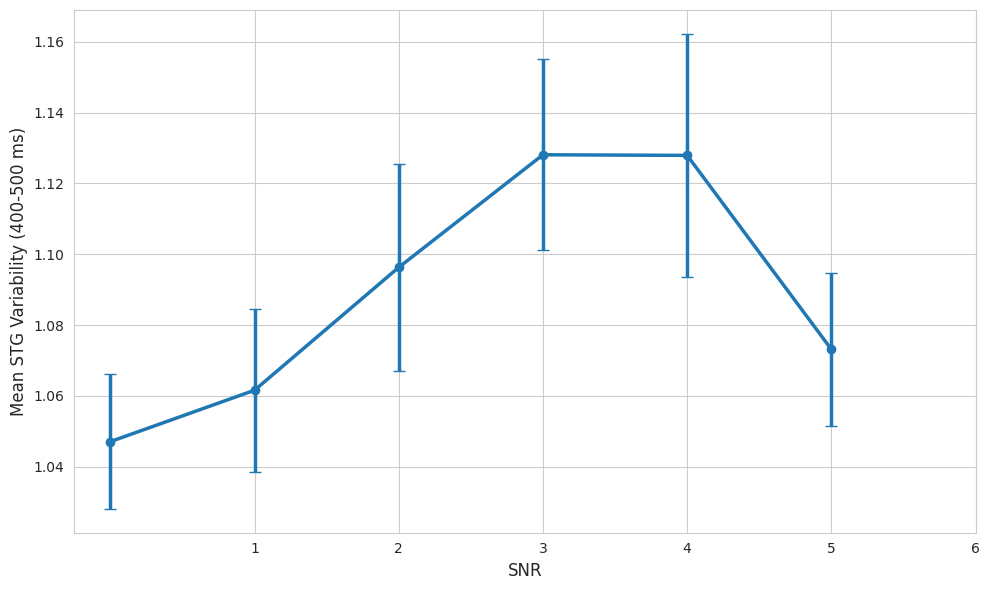

In [15]:
mean_variability_by_snr = np.asarray(mean_variability_by_snr, dtype=float)
ci95_by_snr = np.asarray(ci95_by_snr, dtype=float)
valid = ~np.isnan(mean_variability_by_snr)

plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

plt.errorbar(
    np.arange(0, 6)[valid],
    mean_variability_by_snr[valid],
    yerr=ci95_by_snr[valid],
    fmt='o-',
    capsize=4,
    markersize=6,
    linewidth=2.5,
    color='C0',
    label='Mean ± 95% CI'
)

plt.xticks(np.arange(1, 7))
plt.xlabel('SNR', fontsize=12)
plt.ylabel('Mean STG Variability (400-500 ms)', fontsize=12)
# plt.title('STG Variability Averaged Over 400-500 ms by SNR')
# plt.legend()
plt.tight_layout()
plt.show()

# Passive sorted_by_snr counterpart

In [16]:
task = 'Passive'
file_path = f'Fit_{task}_late'
os.makedirs(file_path, exist_ok=True)
    
snrs_all_parts_passive, state_train_all_parts_passive = [], []
state_train_all_parts_passive_early = []

for part in tqdm(range(20)):
    # part = 18

    # Load data
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref

    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    snr = epochs.metadata['snr'].to_numpy()
    snrs_all_parts_passive.append(snr)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=300, tmax=500, sort_by_snr=True)
        state_train_all_parts_passive.append(state_train)
        state_train_early = lead.STG(epochs_file, tmin=100, tmax=200, sort_by_snr=True)
        state_train_all_parts_passive_early.append(state_train_early)


  0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_338485/1490679894.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_338485/1490679894.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_338485/1490679894.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_338485/1490679894.py:16: RuntimeWarni

In [17]:
state_train_dict_passive = {snr: [] for snr in range(7)}
state_train_dict_passive_early = {snr: [] for snr in range(7)}
for part in range(20):
    max_snr = 7 if part>=10 else 6
    for snr in range(1, max_snr + 1):
        subset = state_train_all_parts_passive[part][snr - 1]
        subset_early = state_train_all_parts_passive_early[part][snr - 1]

        # If the filtered result is a list/array of trials, keep each trial as its own item.
        # If it is already a single trial vector, keep it as a single element.
        if isinstance(subset, np.ndarray):
            if subset.ndim > 1:
                subset = subset.tolist()
                subset_early = subset_early.tolist()
            else:
                subset = [subset]
                subset_early = [subset_early]

        if isinstance(subset, (list, tuple)) and subset and isinstance(subset[0], (list, tuple, np.ndarray)):
            state_train_dict_passive[snr-1].extend(subset)
            state_train_dict_passive_early[snr-1].extend(subset_early)
        else:
            state_train_dict_passive[snr-1].append(subset)
            state_train_dict_passive_early[snr-1].append(subset_early)


In [18]:
for snr in state_train_dict_passive.keys():
    state_train_dict_passive[snr] = np.array(state_train_dict_passive[snr])
    state_train_dict_passive_early[snr] = np.array(state_train_dict_passive_early[snr])


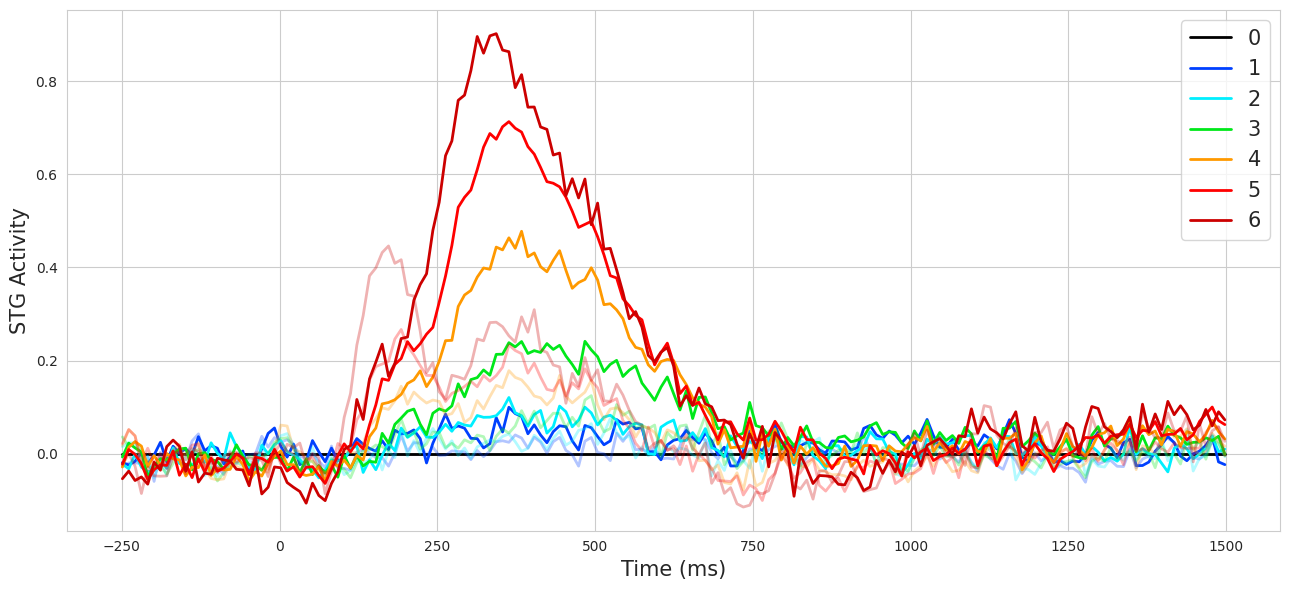

In [19]:
from matplotlib.colors import ListedColormap, Normalize

times = np.linspace(-500, 2000, 250)

plt.figure(figsize=(13, 6))
sns.set_style('whitegrid')

custom_colors = [colormap[i] for i in range(7)]
cmap = ListedColormap(custom_colors, name='snr_custom')
norm = Normalize(vmin=0, vmax=6)

for snr in range(7):
    signal = state_train_dict_passive[snr].mean(axis=0)
    plt.plot(
        times[25:200],
        signal[25:200],
        color=colormap[snr],
        linewidth=2,
        alpha=1,
        label=str(snr)
    )

    signal_early = state_train_dict_passive_early[snr].mean(axis=0)
    plt.plot(
        times[25:200],
        signal_early[25:200],
        color=colormap[snr],
        linewidth=2,
        alpha=0.3,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# colorbar = plt.colorbar(sm, ax=plt.gca(), pad=0.03, ticks=np.arange(1, 7))
# colorbar.set_label('SNR (dB)')
# colorbar.set_ticklabels([str(level) for level in snr_levels])

plt.xlabel('Time (ms)', fontsize=15)
plt.ylabel('STG Activity', fontsize=15)
# plt.title(f'STG Activity by SNR', fontsize=12)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

In [20]:
inter_trial_std_dict_passive = {snr: [] for snr in range(7)}
for part in tqdm(range(20)):
    max_snr = 7 if part>=10 else 6
    for snr in range(max_snr):
        inter_trial_std = np.std(state_train_all_parts_passive[part][snr], axis=0)
        # print(f"Part {part}, SNR {snr}: inter_trial_std shape: {inter_trial_std.shape}")
        inter_trial_std_dict_passive[snr].append(inter_trial_std)

for snr in inter_trial_std_dict_passive.keys():
    inter_trial_std_dict_passive[snr] = np.array(inter_trial_std_dict_passive[snr])

# 95% confidence interval for the variability mean at each SNR level.
# Most common approach: mean +/- 1.96 * SEM, where SEM = SD / sqrt(n)
window = (times >= 400) & (times <= 500)

mean_variability_by_snr_passive = []
ci95_by_snr_passive = []

for snr in range(7):
    if inter_trial_std_dict_passive[snr].size == 0:
        mean_variability_by_snr_passive.append(np.nan)
        ci95_by_snr_passive.append(np.nan)
        continue

    subject_window_means = np.array([
        np.mean(subj_std[window])
        for subj_std in inter_trial_std_dict_passive[snr]
    ])

    mean_val = subject_window_means.mean()
    if subject_window_means.size > 1:
        sem = subject_window_means.std(ddof=1) / np.sqrt(subject_window_means.size)
        ci95 = 1.96 * sem
    else:
        ci95 = 0.0

    mean_variability_by_snr_passive.append(mean_val)
    ci95_by_snr_passive.append(ci95)


  0%|          | 0/20 [00:00<?, ?it/s]

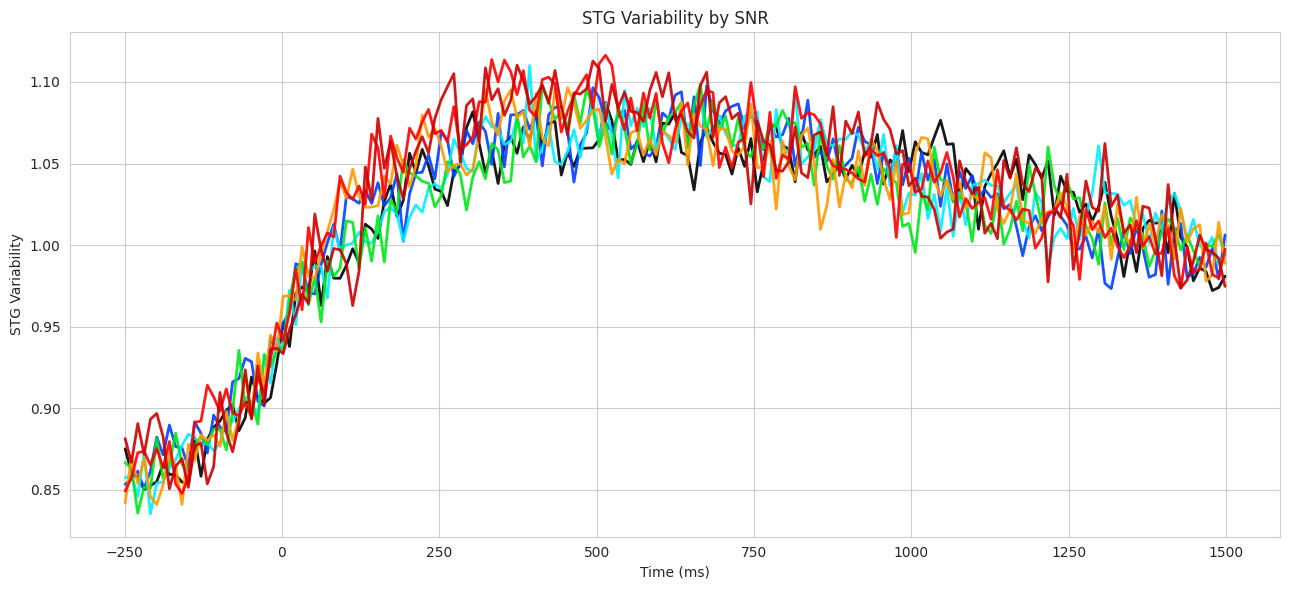

In [21]:
times = np.linspace(-500, 2000, 250)

plt.figure(figsize=(13, 6))
sns.set_style('whitegrid')

snr_levels = [-13, -11, -9, -7, -5, -3]
custom_colors = [colormap[i] for i in range(1, 7)]
cmap = ListedColormap(custom_colors, name='snr_custom')
norm = Normalize(vmin=1, vmax=6)

for snr in range(7):
    signal = inter_trial_std_dict_passive[snr].mean(axis=0)
    plt.plot(
        times[25:200],
        signal[25:200],
        color=colormap[snr],
        linewidth=2,
        alpha=0.9,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# colorbar = plt.colorbar(sm, ax=plt.gca(), pad=0.03)
# colorbar.set_label('SNR')
# colorbar.set_ticks(np.arange(1, 7))
# colorbar.set_ticklabels([str(level) for level in snr_levels])

plt.xlabel('Time (ms)')
plt.ylabel('STG Variability')
plt.title(f'STG Variability by SNR')
plt.tight_layout()
plt.show()

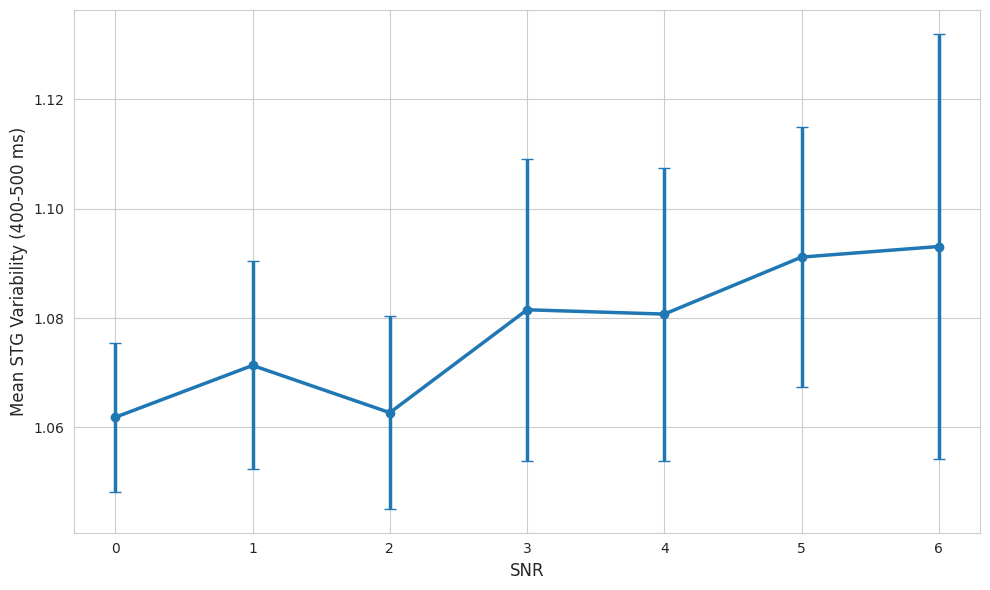

In [22]:
mean_variability_by_snr_passive = np.asarray(mean_variability_by_snr_passive, dtype=float)
ci95_by_snr_passive = np.asarray(ci95_by_snr_passive, dtype=float)
valid = ~np.isnan(mean_variability_by_snr_passive)

plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

plt.errorbar(
    np.arange(0, 7)[valid],
    mean_variability_by_snr_passive[valid],
    yerr=ci95_by_snr_passive[valid],
    fmt='o-',
    capsize=4,
    markersize=6,
    linewidth=2.5,
    color='C0',
    label='Mean ± 95% CI'
)

plt.xticks(np.arange(7))
plt.xlabel('SNR', fontsize=12)
plt.ylabel('Mean STG Variability (400-500 ms)', fontsize=12)
# plt.title('STG Variability Averaged Over 400-500 ms by SNR')
# plt.legend()
plt.tight_layout()
plt.show()

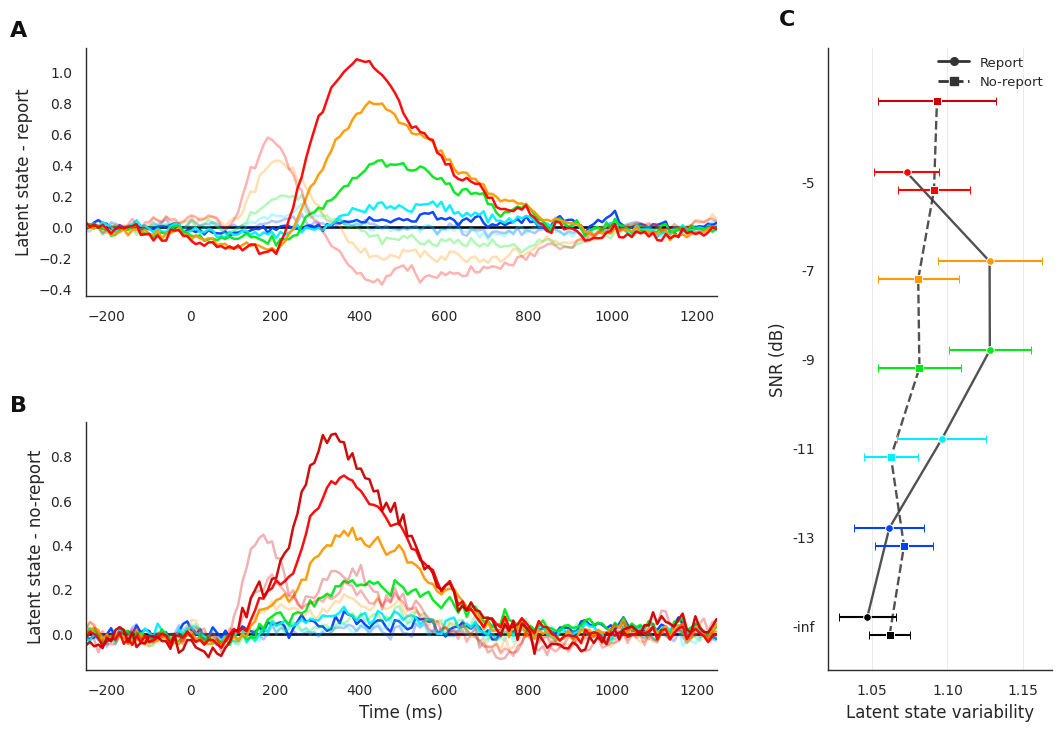

In [46]:
# Final publication-ready figure using only the arrays computed earlier in the notebook.

from matplotlib import font_manager
from matplotlib.lines import Line2D

sns.set_theme(style="white")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
article_font = next(
    (font for font in ("Arial", "Helvetica", "Liberation Sans", "DejaVu Sans") if font in available_fonts),
    "DejaVu Sans",
)
plt.rcParams.update({
    "font.family": article_font,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "axes.linewidth": 1.0,
    "axes.edgecolor": "#2b2b2b",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

passive_colors = [colormap[i] for i in range(7)]
passive_cmap = ListedColormap(passive_colors, name="snr_custom")
passive_norm = Normalize(vmin=0, vmax=6)
snr_colors = [colormap[i] for i in range(1, 7)]
snr_cmap = ListedColormap(snr_colors, name="snr_active")
snr_norm = Normalize(vmin=1, vmax=6)

fig = plt.figure(figsize=(10.5, 7.2), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0], width_ratios=[3.25, 1.15], wspace=0.10, hspace=0.10)
ax_act = fig.add_subplot(gs[0, 0])
ax_pas = fig.add_subplot(gs[1, 0], sharex=ax_act)
ax_var = fig.add_subplot(gs[:, 1])

# Color encodes SNR; opacity distinguishes late from early dynamics.
for snr in range(1, 7):
    color = colormap[snr - 1]
    ax_act.plot(times[25:175], state_train_dict_snrwise[snr].mean(axis=0)[25:175], color=color, linewidth=1.8, alpha=0.95)
    ax_act.plot(times[25:175], state_train_dict_snrwise_early[snr].mean(axis=0)[25:175], color=color, linewidth=1.8, alpha=0.30)
ax_act.set_ylabel("Latent state - report")
ax_act.set_xlim(times[25], times[174])
ax_act.spines["top"].set_visible(False)
ax_act.spines["right"].set_visible(False)
ax_act.tick_params(direction="out")

for snr in range(7):
    color = passive_cmap(passive_norm(snr))
    ax_pas.plot(times[25:175], state_train_dict_passive[snr].mean(axis=0)[25:175], color=color, linewidth=1.8, alpha=0.95)
    ax_pas.plot(times[25:175], state_train_dict_passive_early[snr].mean(axis=0)[25:175], color=color, linewidth=1.8, alpha=0.30)
ax_pas.set_xlabel("Time (ms)")
ax_pas.set_ylabel("Latent state - no-report")
ax_pas.set_xlim(times[25], times[174])
ax_pas.spines["top"].set_visible(False)
ax_pas.spines["right"].set_visible(False)
ax_pas.tick_params(direction="out")

# Panel C: SNR keeps its color; report/no-report use solid/dashed trajectories and circle/square markers.
valid_snr = ~np.isnan(mean_variability_by_snr)
y_snr = np.arange(len(mean_variability_by_snr))[valid_snr]
var_snr = mean_variability_by_snr[valid_snr]
ci_snr = ci95_by_snr[valid_snr]
report_colors = [colormap[i] for i in y_snr]
report_y = y_snr + 0.10
valid_passive = ~np.isnan(mean_variability_by_snr_passive)
y_passive = np.arange(len(mean_variability_by_snr_passive))[valid_passive]
var_passive = mean_variability_by_snr_passive[valid_passive]
ci_passive = ci95_by_snr_passive[valid_passive]
passive_plot_colors = [colormap[i] for i in y_passive]
passive_y = y_passive - 0.10

# Connect the SNR levels so the condition-specific line styles are visible in the plot itself.
ax_var.plot(var_snr, report_y, color="#333333", linestyle="-", linewidth=1.7, alpha=0.85, zorder=2)
ax_var.plot(var_passive, passive_y, color="#333333", linestyle="--", linewidth=1.7, alpha=0.85, zorder=2)
for x, y, xerr, color in zip(var_snr, report_y, ci_snr, report_colors):
    ax_var.errorbar(x, y, xerr=xerr, fmt="o", linestyle="none", capsize=3, capthick=1.2, markersize=5.5, color=color, ecolor=color, elinewidth=1.5, markerfacecolor=color, markeredgecolor="white", markeredgewidth=0.7, zorder=3)
for x, y, xerr, color in zip(var_passive, passive_y, ci_passive, passive_plot_colors):
    ax_var.errorbar(x, y, xerr=xerr, fmt="s", linestyle="none", capsize=3, capthick=1.2, markersize=5.5, color=color, ecolor=color, elinewidth=1.5, markerfacecolor=color, markeredgecolor="white", markeredgewidth=0.7, zorder=3)

legend_handles = [
    Line2D([0], [0], color="#333333", marker="o", linestyle="-", linewidth=2.0, markersize=5.5, label="Report"),
    Line2D([0], [0], color="#333333", marker="s", linestyle="--", linewidth=2.0, markersize=5.5, label="No-report"),
]
ax_var.legend(handles=legend_handles, loc="upper right", frameon=False, handlelength=2.4, borderaxespad=0.2)
snr_labels = np.array(["-inf", "-13", "-11", "-9", "-7", "-5", "-3"])
ax_var.set_yticks(y_snr)
ax_var.set_yticklabels([snr_labels[i] for i in y_snr])
ax_var.set_xlabel("Latent state variability")
ax_var.set_ylabel("SNR (dB)")
# ax_var.set_title("Latent state variability (400-500 ms)", loc="right", pad=8)
ax_var.set_ylim(-0.5, max(y_snr.max(), y_passive.max()) + 0.5)
ax_var.spines["top"].set_visible(False)
ax_var.spines["right"].set_visible(False)
ax_var.tick_params(direction="out")
ax_var.grid(axis="x", color="#d7dbe0", alpha=0.55, linewidth=0.7)
ax_var.set_axisbelow(True)

# Publication-style panel labels, matching the bold scale used in the article figures.
panel_label_style = dict(fontsize=16, fontweight="bold", color="#111111", ha="left", va="bottom")
ax_act.text(-0.12, 1.03, "A", transform=ax_act.transAxes, **panel_label_style)
ax_pas.text(-0.12, 1.03, "B", transform=ax_pas.transAxes, **panel_label_style)
ax_var.text(-0.22, 1.03, "C", transform=ax_var.transAxes, **panel_label_style)

fig.savefig(cwd / "Accumulation_Variability_Publication.pdf", bbox_inches="tight")
fig.savefig(cwd / "Accumulation_Variability_Publication.png", dpi=600, bbox_inches="tight")
plt.show()

# Psychometric curves

In [24]:
psychometric_all_parts = {'Active':[], 'Passive': []}
for part in tqdm(range(20)):

    # for 'Active', audibility is directly asked, and we consider the target heard for aud >= 3.
    task = 'Active'
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref
    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    audibility = epochs.metadata['audibility'].to_numpy()
    snr = epochs.metadata['snr'].to_numpy()
    heard = np.array([np.sum(audibility[snr==snr_val] >= 3) for snr_val in range(1,7)])
    not_heard = np.array([np.sum(audibility[snr==snr_val] < 3) for snr_val in range(1,7)])
    psychometric_all_parts[task].append((heard / (heard + not_heard)))

    # for 'Passive', the MindWandering question (questiontype=3) sometimes asks if the mind content is the target (response=1)
    task = 'Passive'
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref
    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    valid_trials = epochs.metadata['questiontype'].to_numpy() == 3
    snr = epochs.metadata['snr'].to_numpy()[valid_trials]
    response = epochs.metadata['response'].to_numpy()[valid_trials]
    heard = np.array([np.sum(response[snr==snr_val] == 1) for snr_val in range(1,8)])
    not_heard = np.array([np.sum(response[snr==snr_val] != 1) for snr_val in range(1,8)])
    psychometric_all_parts[task].append((heard / (heard + not_heard)))

  0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_338485/3985422549.py:9: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_338485/3985422549.py:21: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_338485/3985422549.py:27: RuntimeWarning: invalid value encountered in divide
  psychometric_all_parts[task].append((heard / (heard + not_heard)))
/tmp/ipykernel_338485/3985422549.py:9: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can 

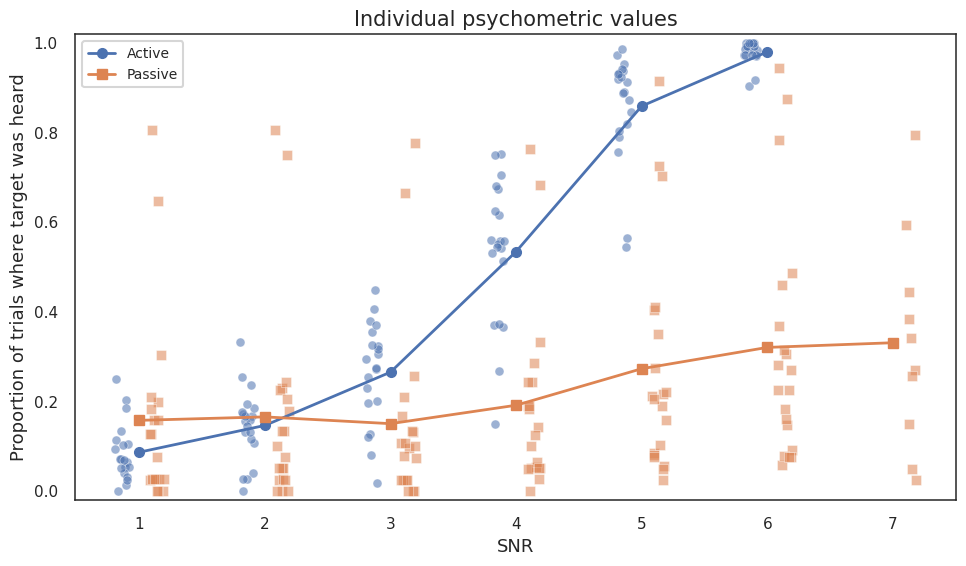

In [25]:
# Rain plot of individual psychometric values by SNR.
# Individual observations are jittered horizontally; no subject-level lines are drawn.
rng = np.random.default_rng(42)

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_style('whitegrid')

psychometric_colors = {'Active': 'C0', 'Passive': 'C1'}
psychometric_markers = {'Active': 'o', 'Passive': 's'}
psychometric_offsets = {'Active': -0.14, 'Passive': 0.14}

for task, values in psychometric_all_parts.items():
    values = np.asarray(values, dtype=float)
    for snr_index in range(values.shape[1]):
        valid_values = values[:, snr_index]
        valid_values = valid_values[~np.isnan(valid_values)]
        x = (
            snr_index + 1
            + psychometric_offsets[task]
            + rng.uniform(-0.06, 0.06, size=valid_values.size)
        )
        ax.scatter(
            x,
            valid_values,
            color=psychometric_colors[task],
            marker=psychometric_markers[task],
            alpha=0.55,
            s=42,
            edgecolors='white',
            linewidths=0.5,
            # label=task if snr_index == 0 else None,
        )

    mean_values = np.nanmean(values, axis=0)
    ax.plot(
        np.arange(1, values.shape[1] + 1),
        mean_values,
        color=psychometric_colors[task],
        marker=psychometric_markers[task],
        linewidth=2,
        markersize=7,
        label=f'{task}',
    )

ax.set_xticks(np.arange(1, 8))
ax.set_xlabel('SNR')
ax.set_ylabel('Proportion of trials where target was heard')
ax.set_ylim(-0.02, 1.02)
ax.set_title('Individual psychometric values')
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

In [26]:
passive_values = np.asarray(psychometric_all_parts['Passive'], dtype=float)[:, 6]
print(
    "Passive, SNR 7's value is {:.3f} ± {:.3f}".format(
        np.nanmean(passive_values),
        np.nanstd(passive_values),
    )
)

Passive, SNR 7's value is 0.331 ± 0.227


# Compare fitted non-linear gain and psychometry

In [27]:
import json
gains_dict = {}
for task in ['Passive', 'Active']:
    for period in ['early', 'late']:
        gains_this_condition = {cat:[] for cat in range(7)}
        for part in range(20):
            file_path = f'Fit_{task}_{period}/GainModulatedModel_part{part}_params'
            with open(file_path, "r") as f:
                params = json.load(f)
            for cat in range(7):
                if cat == 6 and (task == 'Active' or part < 10):
                    gains_this_condition[cat].append(np.nan)
                else:
                    gains_this_condition[cat].append(params[f'g{cat}'])
        gains_dict[f'{task}_{period}'] = gains_this_condition

In [28]:
print(gains_dict['Active_late'].keys(), gains_dict['Passive_late'].keys())

dict_keys([0, 1, 2, 3, 4, 5, 6]) dict_keys([0, 1, 2, 3, 4, 5, 6])


In [29]:
accuracy_all_parts_and_snrs = {'Active':[], 'Passive':[]}
gains_all_parts_and_snrs = {'Active':[], 'Passive':[]}

for task in ['Passive', 'Active']:
    psychometric_values = np.asarray(psychometric_all_parts[task], dtype=float)
    for part in range(20):
        for idx, accuracy in enumerate(psychometric_values[part]):
            if idx==0:
                continue
            accuracy_all_parts_and_snrs[task].append(accuracy)
            gains_all_parts_and_snrs[task].append(gains_dict[f'{task}_late'][idx][part])


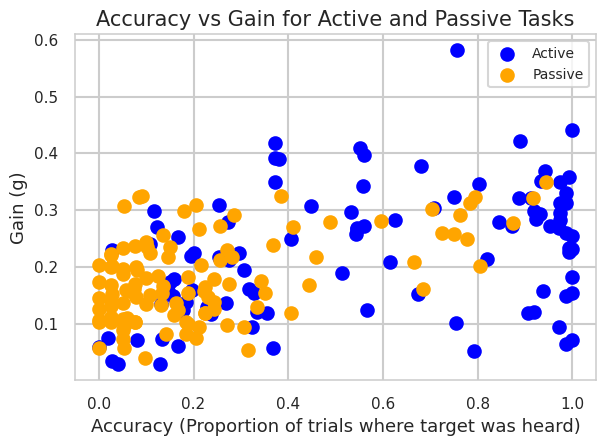

In [30]:
# scatter plot of the accuration vs gain for Active and Passive in different colors
plt.figure()
plt.scatter(accuracy_all_parts_and_snrs['Active'], gains_all_parts_and_snrs['Active'], c='blue', label='Active')
plt.scatter(accuracy_all_parts_and_snrs['Passive'], gains_all_parts_and_snrs['Passive'], c='orange', label='Passive')
plt.xlabel('Accuracy (Proportion of trials where target was heard)')
plt.ylabel('Gain (g)')
plt.title('Accuracy vs Gain for Active and Passive Tasks')
plt.legend()
plt.tight_layout()
plt.show()

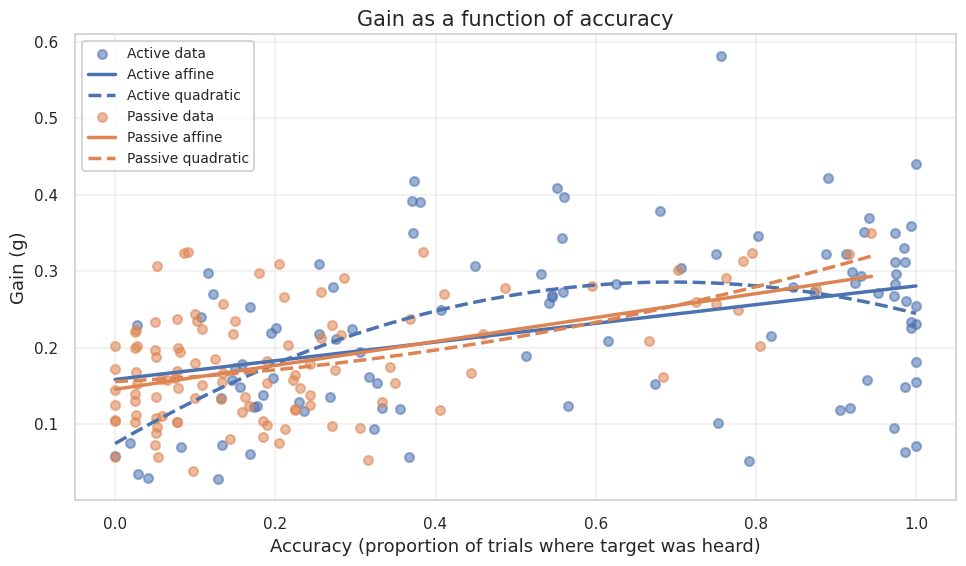

Active: best model = quadratic
  affine    leave-one-out MSE = 0.01076 +/- 0.0157
  quadratic leave-one-out MSE = 0.009746 +/- 0.01397
Passive: best model = quadratic
  affine    leave-one-out MSE = 0.004229 +/- 0.005571
  quadratic leave-one-out MSE = 0.004228 +/- 0.005621


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# Compare affine and quadratic gain = f(accuracy) models independently by condition.
model_specs = {
    "affine": LinearRegression(),
    "quadratic": make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression()),
}
colors = {"Active": "C0", "Passive": "C1"}
models_fitted = {}
cv_results = {}

fig, ax = plt.subplots(figsize=(10, 6))
for task in ["Active", "Passive"]:
    accuracy = np.asarray(accuracy_all_parts_and_snrs[task], dtype=float)
    gain = np.asarray(gains_all_parts_and_snrs[task], dtype=float)
    valid = np.isfinite(accuracy) & np.isfinite(gain)
    accuracy = accuracy[valid]
    gain = gain[valid]

    ax.scatter(accuracy, gain, color=colors[task], alpha=0.55, s=42, label=f"{task} data")
    x_grid = np.linspace(accuracy.min(), accuracy.max(), 200).reshape(-1, 1)
    cv = LeaveOneOut()
    cv_results[task] = {}

    for model_name, model in model_specs.items():
        mse_scores = -cross_val_score(
            model,
            accuracy.reshape(-1, 1),
            gain,
            cv=cv,
            scoring="neg_mean_squared_error",
        )
        cv_results[task][model_name] = {
            "mean_mse": mse_scores.mean(),
            "std_mse": mse_scores.std(ddof=1),
            "fold_mse": mse_scores,
        }

        fitted_model = model.fit(accuracy.reshape(-1, 1), gain)
        models_fitted[(task, model_name)] = fitted_model
        linestyle = "-" if model_name == "affine" else "--"
        ax.plot(
            x_grid,
            fitted_model.predict(x_grid),
            color=colors[task],
            linestyle=linestyle,
            linewidth=2.5,
            label=f"{task} {model_name}",
        )

ax.set_xlabel("Accuracy (proportion of trials where target was heard)")
ax.set_ylabel("Gain (g)")
ax.set_title("Gain as a function of accuracy")
ax.legend(frameon=True)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Lower mean held-out MSE indicates better robustness to overfitting.
for task, results in cv_results.items():
    best_model = min(results, key=lambda name: results[name]["mean_mse"])
    print(f"{task}: best model = {best_model}")
    for model_name, result in results.items():
        print(
            f"  {model_name:9s} leave-one-out MSE = "
            f"{result['mean_mse']:.4g} +/- {result['std_mse']:.4g}"
        )


In [32]:
from scipy.stats import t

# Bootstrap stability of the quadratic coefficient.
# The bootstrap probability is descriptive: it is not a binomial p-value,
# because all resamples come from the same observed dataset.
rng = np.random.default_rng(42)
n_bootstrap = 5000
bootstrap_results = {}

for task in ["Active", "Passive"]:
    accuracy = np.asarray(accuracy_all_parts_and_snrs[task], dtype=float)
    gain = np.asarray(gains_all_parts_and_snrs[task], dtype=float)
    valid = np.isfinite(accuracy) & np.isfinite(gain)
    accuracy = accuracy[valid]
    gain = gain[valid]

    design = np.column_stack([np.ones(accuracy.size), accuracy, accuracy**2])
    global_coefficients = np.linalg.lstsq(design, gain, rcond=None)[0]
    global_quadratic_coefficient = global_coefficients[2]

    bootstrap_coefficients = np.empty(n_bootstrap)
    for bootstrap_index in range(n_bootstrap):
        sampled_indices = rng.integers(0, accuracy.size, size=accuracy.size)
        bootstrap_design = design[sampled_indices]
        bootstrap_gain = gain[sampled_indices]
        bootstrap_coefficients[bootstrap_index] = np.linalg.lstsq(
            bootstrap_design,
            bootstrap_gain,
            rcond=None,
        )[0][2]

    probability_at_least_global = np.mean(
        bootstrap_coefficients >= global_quadratic_coefficient
    )
    bootstrap_ci = np.quantile(bootstrap_coefficients, [0.025, 0.975])

    # Standard one-sided OLS test of H0: beta_2 <= 0 versus H1: beta_2 > 0.
    residuals = gain - design @ global_coefficients
    residual_variance = np.sum(residuals**2) / (accuracy.size - design.shape[1])
    covariance = residual_variance * np.linalg.inv(design.T @ design)
    standard_error = np.sqrt(covariance[2, 2])
    t_statistic = global_quadratic_coefficient / standard_error
    one_sided_p = t.sf(t_statistic, df=accuracy.size - design.shape[1])

    bootstrap_results[task] = {
        "global_quadratic_coefficient": global_quadratic_coefficient,
        "probability_at_least_global": probability_at_least_global,
        "bootstrap_ci95": bootstrap_ci,
        "t_statistic": t_statistic,
        "one_sided_p": one_sided_p,
    }

    print(f"{task}")
    print(f"  global degree-2 coefficient: {global_quadratic_coefficient:.6g}")
    print(
        "  bootstrap P(coefficient >= global coefficient): "
        f"{probability_at_least_global:.3f}"
    )
    print(
        "  bootstrap 95% CI: "
        f"[{bootstrap_ci[0]:.6g}, {bootstrap_ci[1]:.6g}]"
    )
    print(
        "  one-sided OLS test H0: degree-2 coefficient <= 0: "
        f"t = {t_statistic:.3f}, p = {one_sided_p:.4g}"
    )


Active
  global degree-2 coefficient: -0.43813
  bootstrap P(coefficient >= global coefficient): 0.499
  bootstrap 95% CI: [-0.678981, -0.188178]
  one-sided OLS test H0: degree-2 coefficient <= 0: t = -3.509, p = 0.9997
Passive
  global degree-2 coefficient: 0.129936
  bootstrap P(coefficient >= global coefficient): 0.493
  bootstrap 95% CI: [-0.0631443, 0.307585]
  one-sided OLS test H0: degree-2 coefficient <= 0: t = 1.234, p = 0.1099


# Compute the velocity of dynamics with a savgol filter

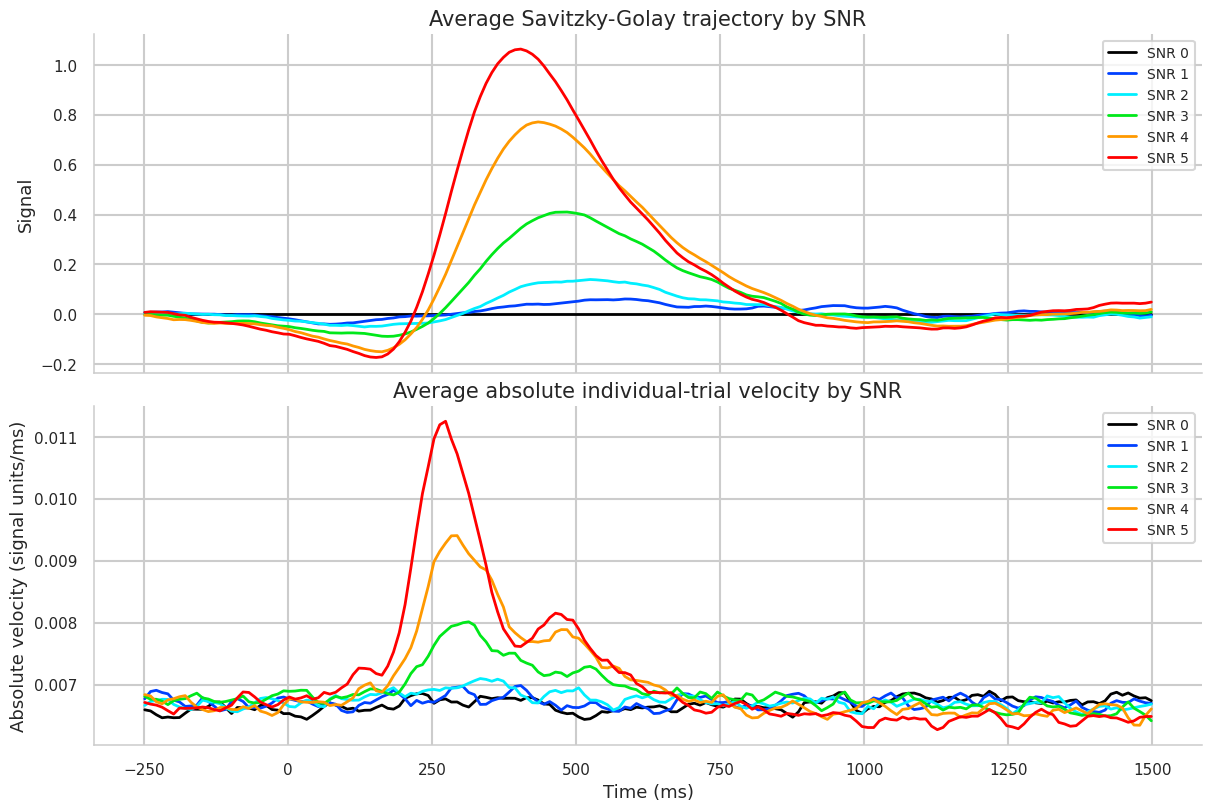

In [33]:
from scipy.signal import savgol_filter

# Savitzky-Golay parameters: change these values to adjust the smoothing.
savgol_window_length = 25  # Must be odd and smaller than the signal length.
savgol_polyorder = 3       # Polynomial order; must be smaller than the window length.
savgol_mode = "interp"     # Boundary handling mode.

snr_keys = sorted(state_train_dict_snrwise.keys())
trajectory_snrwise = {}
velocity_snrwise = {}
absolute_velocity_snrwise = {}

# Filter each trial independently, then average the filtered results within each SNR.
for snr in snr_keys:
    trials = np.asarray(state_train_dict_snrwise[snr], dtype=float)
    if trials.ndim == 1:
        trials = trials[np.newaxis, :]
    if trials.ndim != 2:
        raise ValueError(f"Expected 1D or 2D trial data for SNR {snr}, got shape {trials.shape}.")
    if trials.shape[0] == 0:
        continue
    if savgol_window_length % 2 == 0:
        raise ValueError("savgol_window_length must be odd.")
    if savgol_window_length > trials.shape[1]:
        raise ValueError("savgol_window_length must be smaller than the signal length.")
    if savgol_polyorder >= savgol_window_length:
        raise ValueError("savgol_polyorder must be smaller than savgol_window_length.")

    # Use the time vector to convert the derivative from samples to signal units per ms.
    sampling_interval = float(np.mean(np.diff(times)))
    trajectory_snrwise[snr] = savgol_filter(
        trials,
        window_length=savgol_window_length,
        polyorder=savgol_polyorder,
        deriv=0,
        delta=sampling_interval,
        axis=-1,
        mode=savgol_mode,
    )
    velocity_snrwise[snr] = savgol_filter(
        trials,
        window_length=savgol_window_length,
        polyorder=savgol_polyorder,
        deriv=1,
        delta=sampling_interval,
        axis=-1,
        mode=savgol_mode,
    )
    absolute_velocity_snrwise[snr] = np.abs(velocity_snrwise[snr])

# Exclude the beginning and end where Savitzky-Golay edge effects are strongest.
plot_slice = slice(25, 200)
plot_times = times[plot_slice]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
colors = plt.get_cmap("viridis")(np.linspace(0, 1, len(snr_keys)))

for snr in snr_keys:
    if snr not in trajectory_snrwise:
        continue
    axes[0].plot(
        plot_times,
        trajectory_snrwise[snr].mean(axis=0)[plot_slice],
        color=colormap[snr-1],
        linewidth=2.0,
        label=f"SNR {snr-1}",
    )
    axes[1].plot(
        plot_times,
        absolute_velocity_snrwise[snr].mean(axis=0)[plot_slice],
        color=colormap[snr-1],
        linewidth=2.0,
        label=f"SNR {snr-1}",
    )

axes[0].set_ylabel("Signal")
axes[0].set_title("Average Savitzky-Golay trajectory by SNR")
axes[0].legend(frameon=True)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Absolute velocity (signal units/ms)")
axes[1].set_title("Average absolute individual-trial velocity by SNR")
axes[1].legend(frameon=True)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.show()

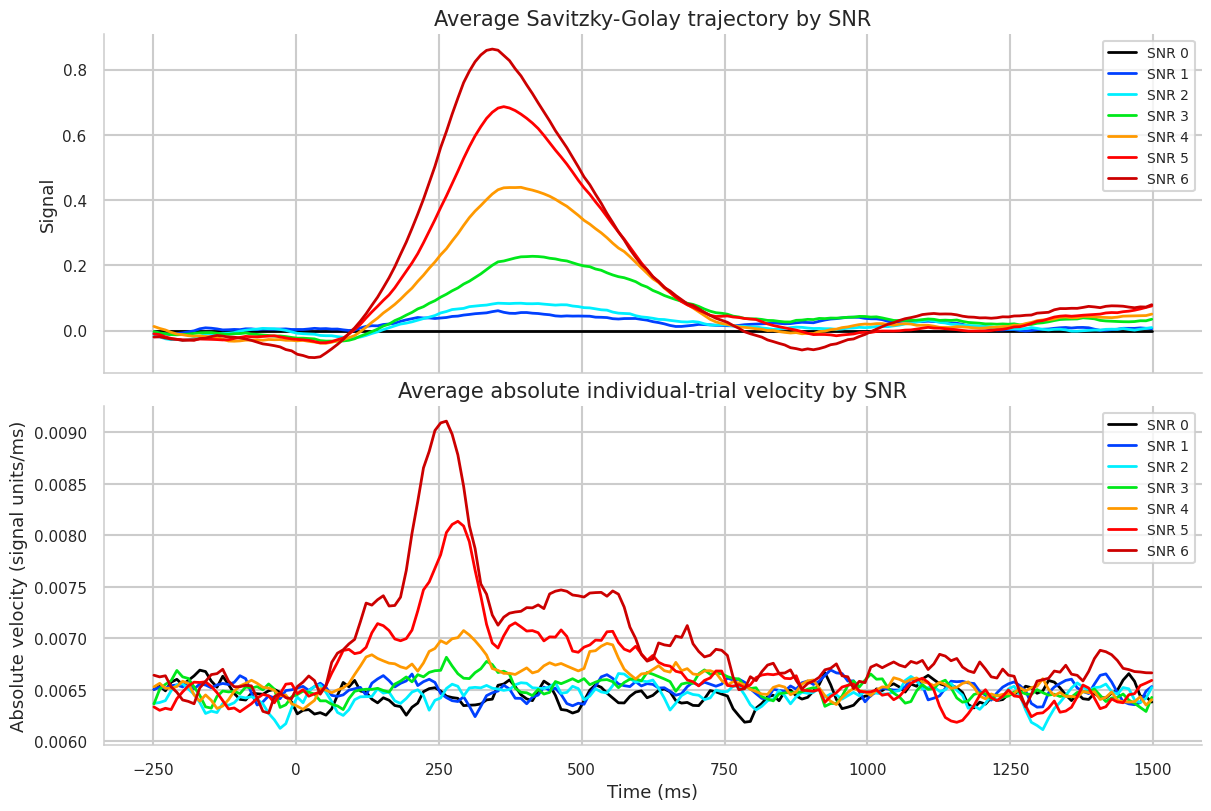

In [34]:
from scipy.signal import savgol_filter

# Savitzky-Golay parameters: change these values to adjust the smoothing.
savgol_window_length = 25  # Must be odd and smaller than the signal length.
savgol_polyorder = 3       # Polynomial order; must be smaller than the window length.
savgol_mode = "interp"     # Boundary handling mode.

snr_keys = sorted(state_train_dict_passive.keys())
trajectory_snrwise = {}
velocity_snrwise = {}
absolute_velocity_snrwise = {}

# Filter each trial independently, then average the filtered results within each SNR.
for snr in snr_keys:
    trials = np.asarray(state_train_dict_passive[snr], dtype=float)
    if trials.ndim == 1:
        trials = trials[np.newaxis, :]
    if trials.ndim != 2:
        raise ValueError(f"Expected 1D or 2D trial data for SNR {snr}, got shape {trials.shape}.")
    if trials.shape[0] == 0:
        continue
    if savgol_window_length % 2 == 0:
        raise ValueError("savgol_window_length must be odd.")
    if savgol_window_length > trials.shape[1]:
        raise ValueError("savgol_window_length must be smaller than the signal length.")
    if savgol_polyorder >= savgol_window_length:
        raise ValueError("savgol_polyorder must be smaller than savgol_window_length.")

    # Use the time vector to convert the derivative from samples to signal units per ms.
    sampling_interval = float(np.mean(np.diff(times)))
    trajectory_snrwise[snr] = savgol_filter(
        trials,
        window_length=savgol_window_length,
        polyorder=savgol_polyorder,
        deriv=0,
        delta=sampling_interval,
        axis=-1,
        mode=savgol_mode,
    )
    velocity_snrwise[snr] = savgol_filter(
        trials,
        window_length=savgol_window_length,
        polyorder=savgol_polyorder,
        deriv=1,
        delta=sampling_interval,
        axis=-1,
        mode=savgol_mode,
    )
    absolute_velocity_snrwise[snr] = np.abs(velocity_snrwise[snr])

# Exclude the beginning and end where Savitzky-Golay edge effects are strongest.
plot_slice = slice(25, 200)
plot_times = times[plot_slice]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
colors = plt.get_cmap("viridis")(np.linspace(0, 1, len(snr_keys)))

for snr in snr_keys:
    if snr not in trajectory_snrwise:
        continue
    axes[0].plot(
        plot_times,
        trajectory_snrwise[snr].mean(axis=0)[plot_slice],
        color=colormap[snr],
        linewidth=2.0,
        label=f"SNR {snr}",
    )
    axes[1].plot(
        plot_times,
        absolute_velocity_snrwise[snr].mean(axis=0)[plot_slice],
        color=colormap[snr],
        linewidth=2.0,
        label=f"SNR {snr}",
    )

axes[0].set_ylabel("Signal")
axes[0].set_title("Average Savitzky-Golay trajectory by SNR")
axes[0].legend(frameon=True)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Absolute velocity (signal units/ms)")
axes[1].set_title("Average absolute individual-trial velocity by SNR")
axes[1].legend(frameon=True)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.show()

In [35]:
heard_series_thresh_all_parts, not_heard_series_thresh_all_parts = [], []
for part in range(20):

    # for 'Active', audibility is directly asked, and we consider the target heard for aud >= 3.
    task = 'Active'
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref
    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    audibility = epochs.metadata['audibility'].to_numpy()
    snr = epochs.metadata['snr'].to_numpy()

    heard_thresh = np.array(audibility[snr==4] >= 3)
    heard_thresh_series = state_train_all_parts_snrwise[part][3][heard_thresh]
    not_heard_thresh_series = state_train_all_parts_snrwise[part][3][~heard_thresh]

    heard_series_thresh_all_parts += heard_thresh_series.tolist()
    not_heard_series_thresh_all_parts += not_heard_thresh_series.tolist()

/tmp/ipykernel_338485/2466692653.py:9: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_338485/2466692653.py:9: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_338485/2466692653.py:9: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_338485/2466692653.py:9: RuntimeWarning: 

In [36]:
print(len(heard_series_thresh_all_parts), len(not_heard_series_thresh_all_parts))

1612 1398


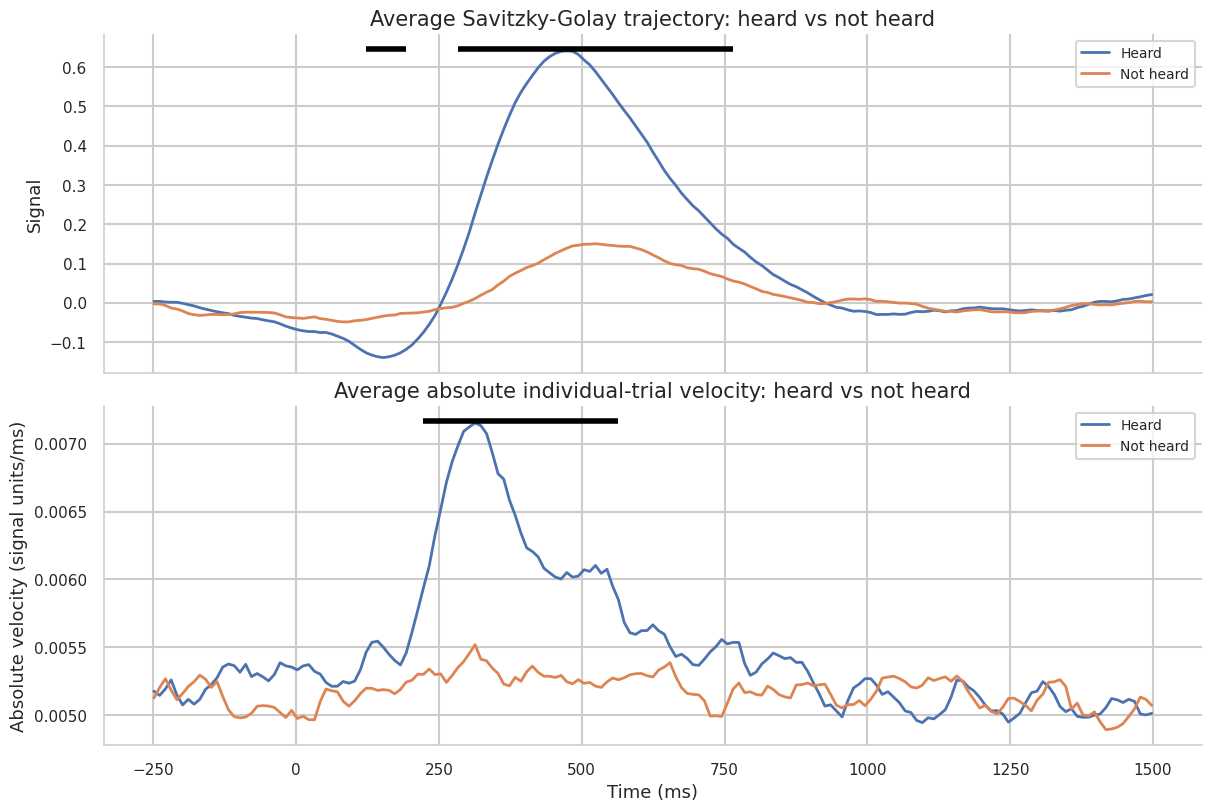

In [37]:
from scipy.signal import savgol_filter
from scipy.stats import ttest_ind

# Compute average trajectories and average absolute velocities for heard vs not-heard trials.
savgol_window_length = 31
savgol_polyorder = 3
savgol_mode = "interp"
sampling_interval = float(np.mean(np.diff(times)))
plot_slice = slice(25, 200)
plot_times = times[plot_slice]

trial_groups = {
    "Heard": heard_series_thresh_all_parts,
    "Not heard": not_heard_series_thresh_all_parts,
}
trajectory_by_group = {}
absolute_velocity_by_group = {}

for group_name, subject_trials in trial_groups.items():
    trajectories = []
    absolute_velocities = []

    for trials in subject_trials:
        trials = np.asarray(trials, dtype=float)
        if trials.size == 0:
            continue
        if trials.ndim == 1:
            trials = trials[np.newaxis, :]
        if trials.ndim != 2:
            raise ValueError(
                f"Expected 1D or 2D trial data for {group_name}, got shape {trials.shape}."
            )
        if savgol_window_length >= trials.shape[1]:
            raise ValueError("savgol_window_length must be smaller than the signal length.")

        smoothed_trials = savgol_filter(
            trials,
            window_length=savgol_window_length,
            polyorder=savgol_polyorder,
            deriv=0,
            delta=sampling_interval,
            axis=-1,
            mode=savgol_mode,
        )
        velocity_trials = savgol_filter(
            trials,
            window_length=savgol_window_length,
            polyorder=savgol_polyorder,
            deriv=1,
            delta=sampling_interval,
            axis=-1,
            mode=savgol_mode,
        )
        trajectories.append(smoothed_trials.mean(axis=0))
        absolute_velocities.append(np.abs(velocity_trials).mean(axis=0))

    trajectory_by_group[group_name] = np.asarray(trajectories)
    absolute_velocity_by_group[group_name] = np.asarray(absolute_velocities)

# Test the two trial-level curves independently at each time point.
heard_trajectories = trajectory_by_group["Heard"]
not_heard_trajectories = trajectory_by_group["Not heard"]
heard_velocities = absolute_velocity_by_group["Heard"]
not_heard_velocities = absolute_velocity_by_group["Not heard"]

_, trajectory_p_values = ttest_ind(
    heard_trajectories,
    not_heard_trajectories,
    axis=0,
    equal_var=False,
    nan_policy="omit",
)
_, velocity_p_values = ttest_ind(
    heard_velocities,
    not_heard_velocities,
    axis=0,
    equal_var=False,
    nan_policy="omit",
)

alpha = 0.05
trajectory_significant = (trajectory_p_values < alpha / plot_times.size)[plot_slice]
velocity_significant = (velocity_p_values < alpha / plot_times.size)[plot_slice]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True,
    constrained_layout=True,
)
colors = {"Heard": "C0", "Not heard": "C1"}

for group_name in trial_groups:
    if trajectory_by_group[group_name].size == 0:
        continue
    axes[0].plot(
        plot_times,
        trajectory_by_group[group_name].mean(axis=0)[plot_slice],
        color=colors[group_name],
        linewidth=2.0,
        label=group_name,
    )
    axes[1].plot(
        plot_times,
        absolute_velocity_by_group[group_name].mean(axis=0)[plot_slice],
        color=colors[group_name],
        linewidth=2.0,
        label=group_name,
    )

axes[0].set_ylabel("Signal")
axes[0].set_title("Average Savitzky-Golay trajectory: heard vs not heard")
axes[0].legend(frameon=True)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Absolute velocity (signal units/ms)")
axes[1].set_title("Average absolute individual-trial velocity: heard vs not heard")
axes[1].legend(frameon=True)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# Draw black bars over contiguous Bonferroni-significant time intervals.
for ax, significant in zip(axes, [trajectory_significant, velocity_significant]):
    y_min, y_max = ax.get_ylim()
    bar_y = y_max - 0.04 * (y_max - y_min)
    padded = np.r_[False, significant, False]
    starts = np.flatnonzero(np.diff(padded.astype(int)) == 1)
    ends = np.flatnonzero(np.diff(padded.astype(int)) == -1)
    for start, end in zip(starts, ends):
        ax.hlines(bar_y, plot_times[start], plot_times[end - 1], color="black", linewidth=4)

plt.show()